# PDA-3. Библиотека SciPy

# 1. Что такое библиотека SciPy?

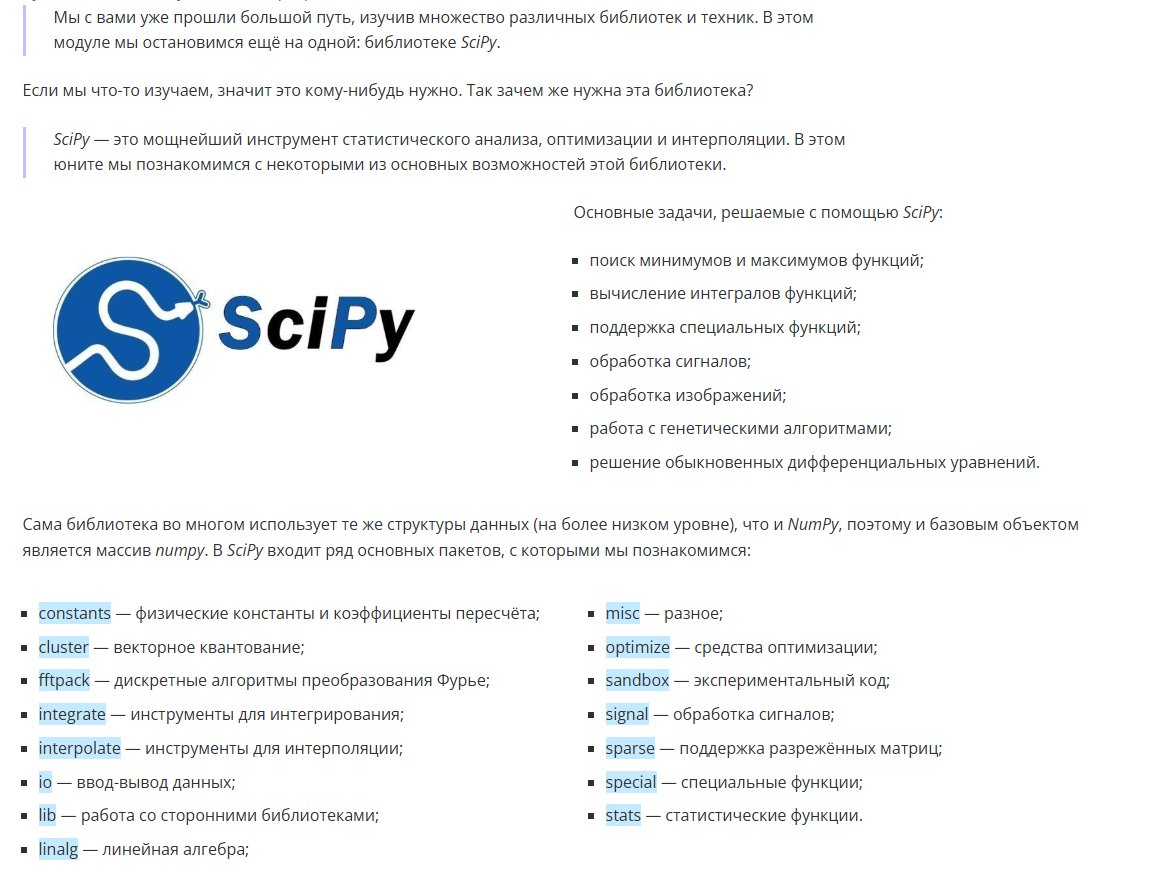

В рамках курса у нас будут как теоретические, так и небольшие практические занятия по работе со SciPy. Для практики необходимо установить саму библиотеку на локальную машину. Это можно сделать командой:

In [ ]:
# pip install scipy==1.6.2

После установки давайте проверим, что всё работает, и заодно познакомимся с одной важной спецификой библиотеки.

1. Импортируем пакет с оптимизаторами.

In [6]:
from scipy import optimize

2. Для просмотра документации импортируем numpy.

In [7]:
import numpy as np

3. Посмотрим документацию минимизатора функции (что он из себя представляет, мы разберём далее).

In [8]:
np.info(optimize.fmin)

 fmin(func, x0, args=(), xtol=0.0001, ftol=0.0001, maxiter=None, maxfun=None,
      full_output=0, disp=1, retall=0, callback=None, initial_simplex=None)

Minimize a function using the downhill simplex algorithm.

This algorithm only uses function values, not derivatives or second
derivatives.

Parameters
----------
func : callable func(x,*args)
    The objective function to be minimized.
x0 : ndarray
    Initial guess.
args : tuple, optional
    Extra arguments passed to func, i.e., ``f(x,*args)``.
xtol : float, optional
    Absolute error in xopt between iterations that is acceptable for
    convergence.
ftol : number, optional
    Absolute error in func(xopt) between iterations that is acceptable for
    convergence.
maxiter : int, optional
    Maximum number of iterations to perform.
maxfun : number, optional
    Maximum number of function evaluations to make.
full_output : bool, optional
    Set to True if fopt and warnflag outputs are desired.
disp : bool, optional
    Set to Tru

Конечно, традиционная команда help тоже сработает, но разработчики рекомендуют использовать np.info, особенно в интерактивных сессиях (в терминале), чтобы не получить сбой. 

На этом можно закончить это небольшое введение. Давайте проверим, что мы узнали!

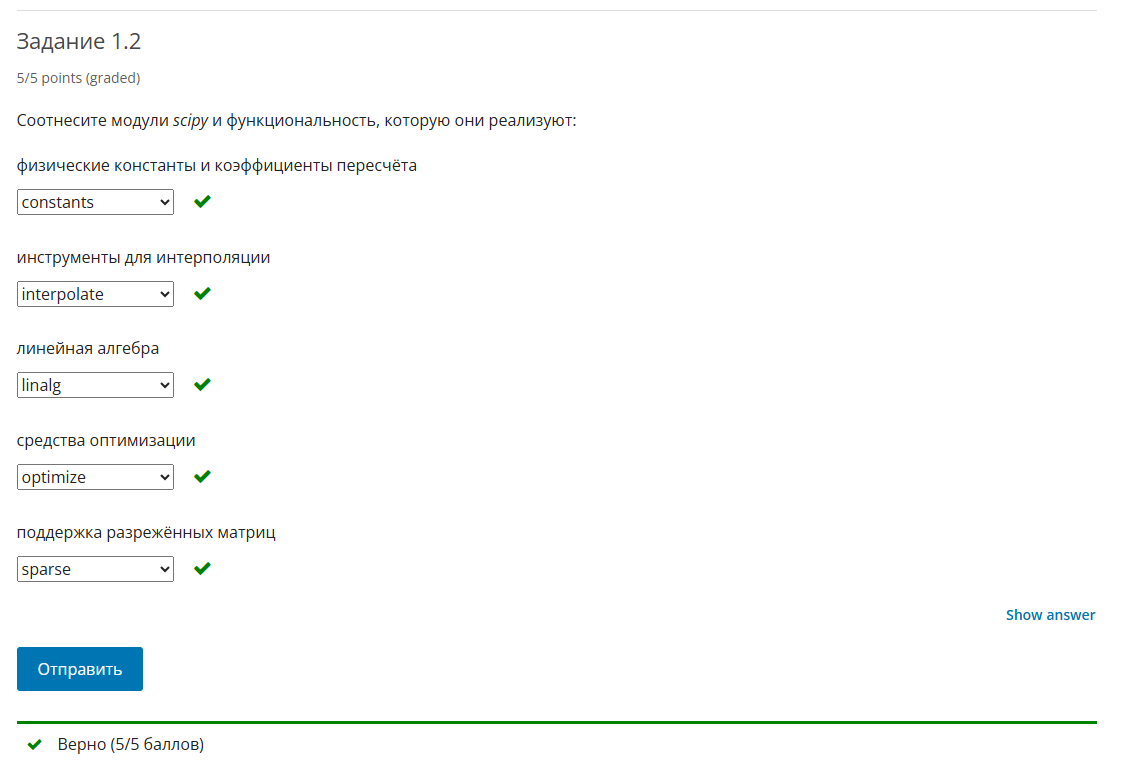

# 2. Sparse-матрицы

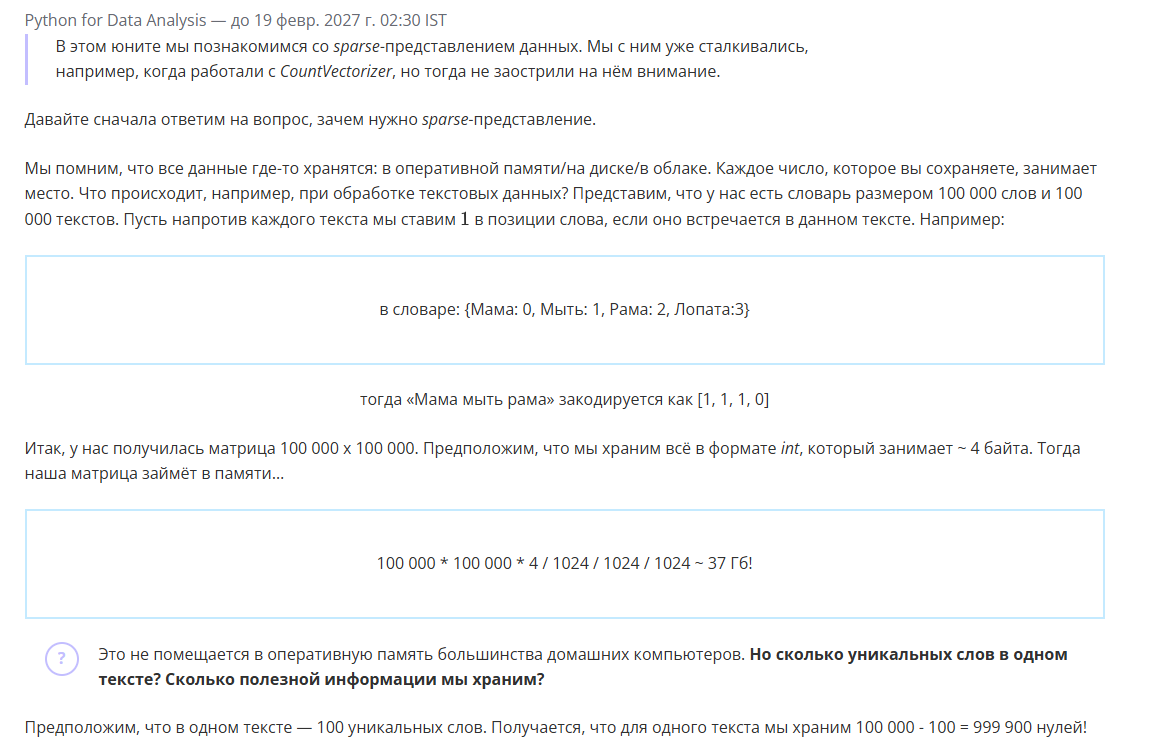

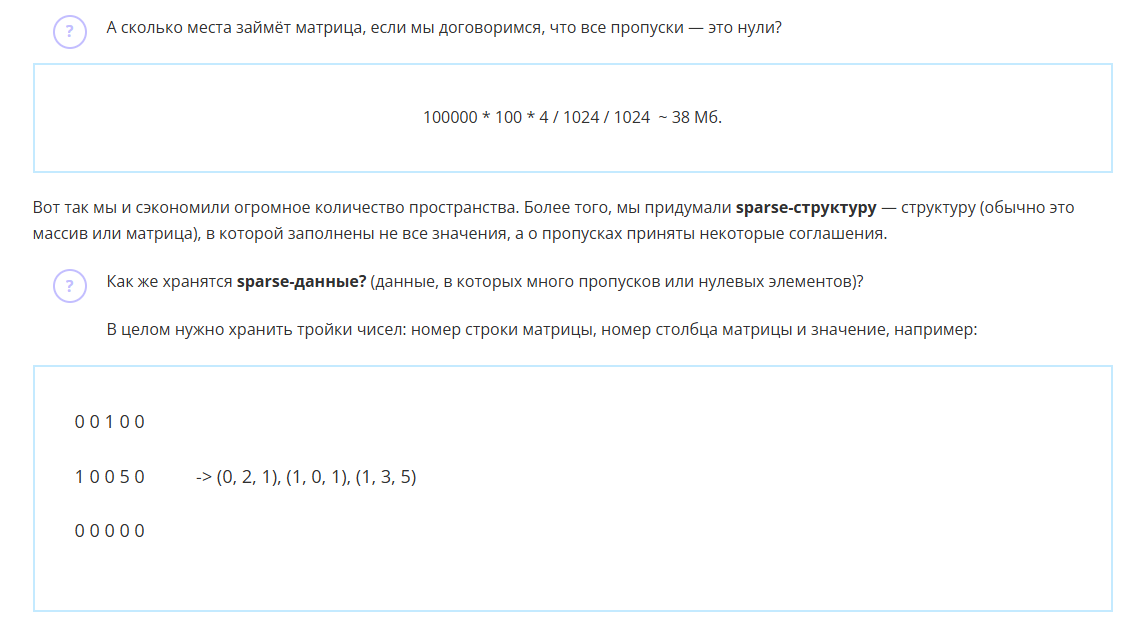

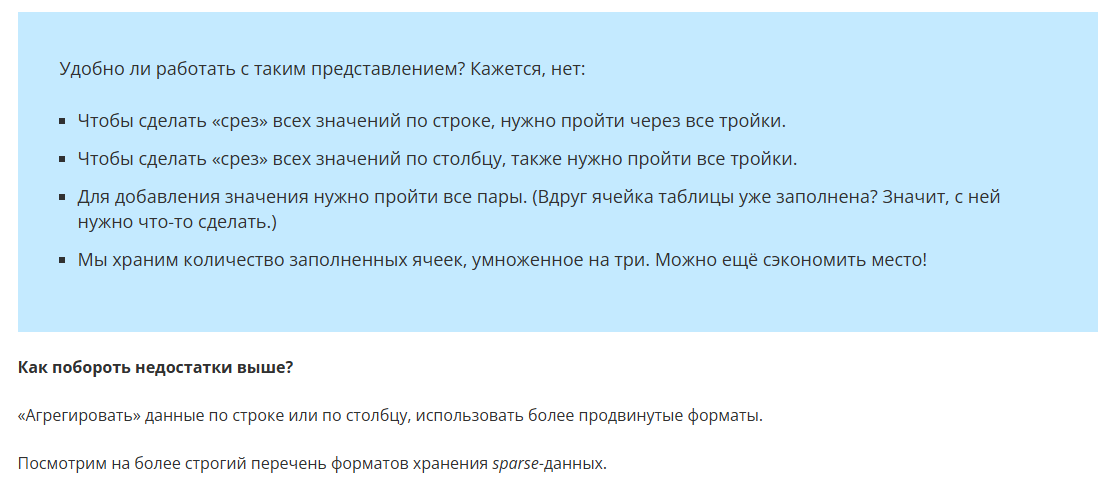

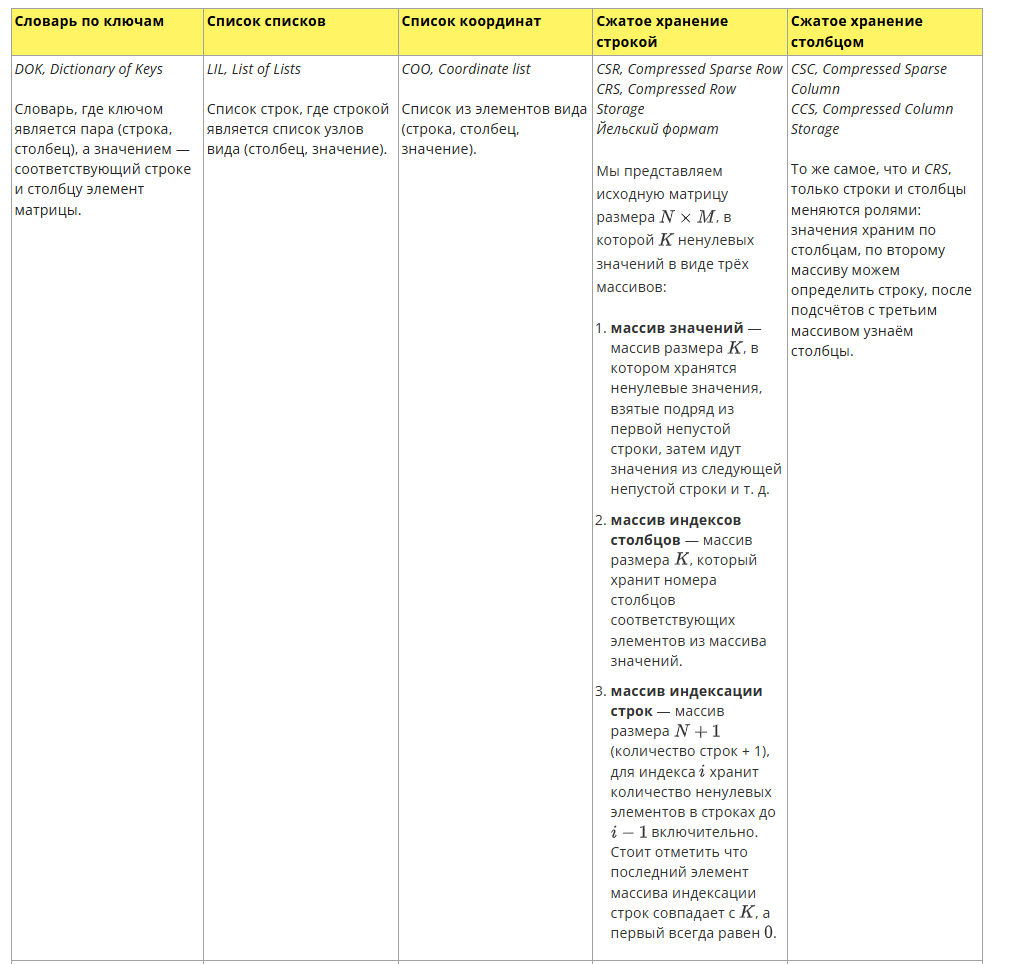

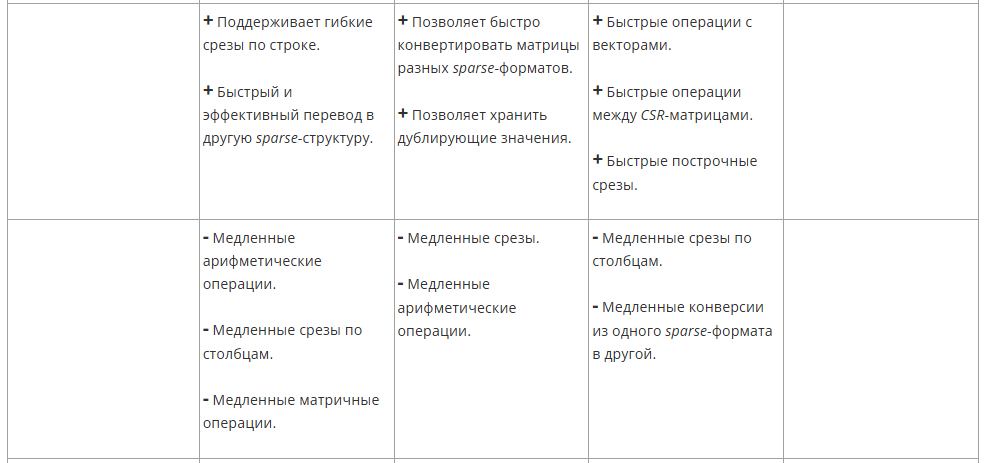

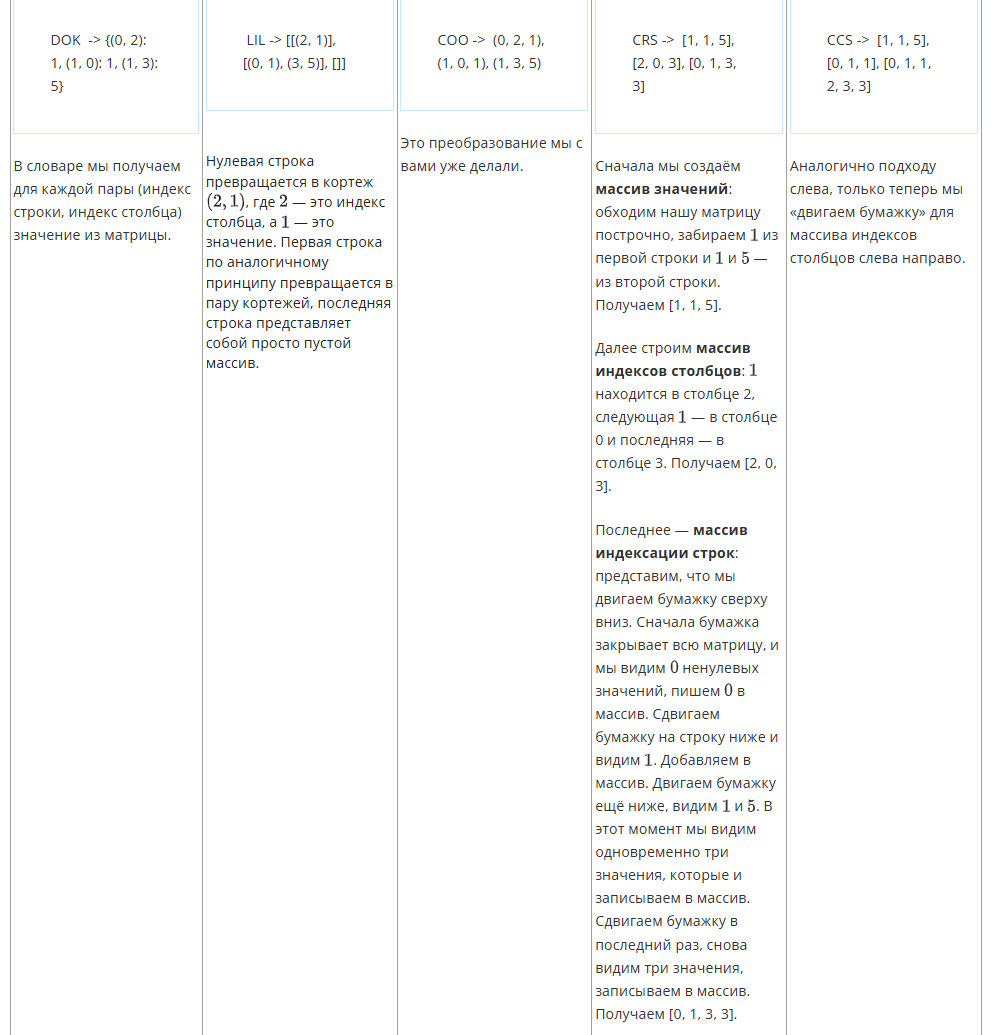

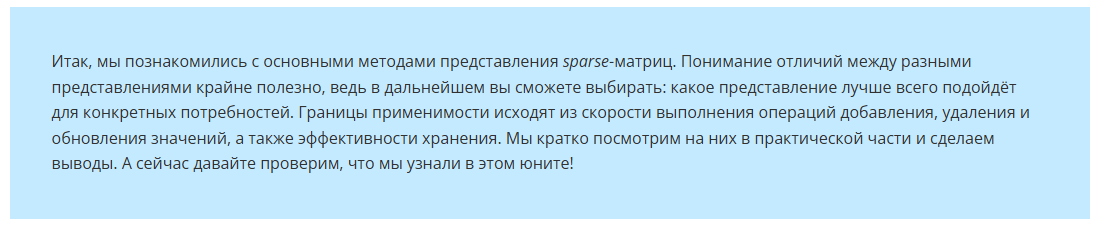

# 3. Sparse-матрицы. Практика

→ Давайте теперь посмотрим, как это работает на практике. Sparse-структуры определены в scipy в пакете sparse (как ни странно). Заглянем в него! 

Он включает следующие классы:

- bsr_matrix — block Sparse Row matrix;
- coo_matrix — a sparse matrix in COOrdinate format;
- csc_matrix — compressed sparse column matrix;
- csr_matrix — сompressed sparse row matrix;
- dia_matrix — sparse matrix with DIAgonal storage;
- dok_matrix — dictionary of keys based sparse matrix;
- lil_matrix — row-based list of lists sparse matrix.

Мы не разбирали работу bsr- и dia-хранилища. В рамках этого модуля мы не будем их рассматривать — они не сильно распространены и, скорее всего, вы с ними не столкнётесь, а полученных знаний вам хватит для освоения и других техник.

Также пакет включает в себя ряд методов для работы со sparse-матрицами, с которыми мы познакомимся далее. Давайте узнаем, как создавать матрицы разных типов.

1. Научимся создавать матрицы разных типов:

In [9]:
from scipy import sparse
import numpy as np

# CSR-матрица
sample_csr = sparse.csr_matrix([[1, 2, 0], [0, 0, 3], [4, 0, 5]])
row = np.array([0, 2, 2, 0, 1, 2])
col = np.array([0, 0, 1, 2, 2, 2])
data = np.array([1, 2, 3, 4, 5, 6])

# CSС-матрица
sample_csc = sparse.csc_matrix((data, (row, col)), shape=(3, 3))

I = np.array([0,3,1,0])
J = np.array([0,3,1,2])
V = np.array([4,5,7,9])

# COO-матрица
sample_coo = sparse.coo_matrix((V,(I,J)),shape=(4,4))
# LIL матрица
sample_lil = sparse.lil_matrix((3, 3))

# DOK-матрица
sample_dok = sparse.dok_matrix((5, 5), dtype=np.float32)

2. Итак, мы научились создавать матрицы разных видов. Давайте научимся их заполнять. К счастью, большая часть механики уже реализована за нас:

In [10]:
from numpy.random import rand

sample_lil[0, :3] = np.ones(3)
sample_lil[1, :3] = sample_lil[0, :3]
sample_lil.setdiag(rand(3))

for i in range(5):
    for j in range(5):
        sample_dok [i, j] = i + j

К сожалению, COO-, CSC-, CSR-матрицы очень плохо изменяемы после создания — большая часть операций для них не определена. Поэтому COO-матрицы будем считать неизменяемыми. Для обновления CSC и CSR используется матричное сложение или перевод в dense-формат с последующим обновлением и переводом обратно в sparse-формат. Давайте посмотрим, как это делается, на примере CSR: